# Probing Transformer Representations for Deceptive Behaviour Detection

Thin Colab wrapper. Runs entirely on the free T4 tier with the default `Qwen/Qwen3-0.6B` config.

In [ ]:
!pip install -q -r requirements.txt

In [18]:
from huggingface_hub import login

login()

In [20]:
!{sys.executable} -m scripts.run_pipeline --config configs/config.yaml


Running: c:\Users\ansh\Downloads\probing-deceptive-representations\venv\Scripts\python.exe -m scripts.extract_activations --config configs/config.yaml
Loading model: Qwen/Qwen3-0.6B
Loaded Qwen/Qwen3-0.6B (28 layers, hidden size 1024) on cpu
Loading dataset: Cadenza-Labs/liars-bench / instructed-deception
Loaded 2000 balanced examples
Saved last_token activations -> results\activations\instructed-deception_last_token.pt
Saved mean activations -> results\activations\instructed-deception_mean.pt

Running: c:\Users\ansh\Downloads\probing-deceptive-representations\venv\Scripts\python.exe -m scripts.train_probes --config configs/config.yaml
[last_token] activations shape: (29, 2000, 1024)
    layer  cv_mean_accuracy  test_accuracy  test_auroc
0       0          0.519375         0.5100    0.519138
1       1          0.811875         0.8400    0.907050
2       2          0.824375         0.8200    0.905425
3       3          0.812500         0.8575    0.903313
4       4          0.820625    

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 382.26it/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 433.49it/s]


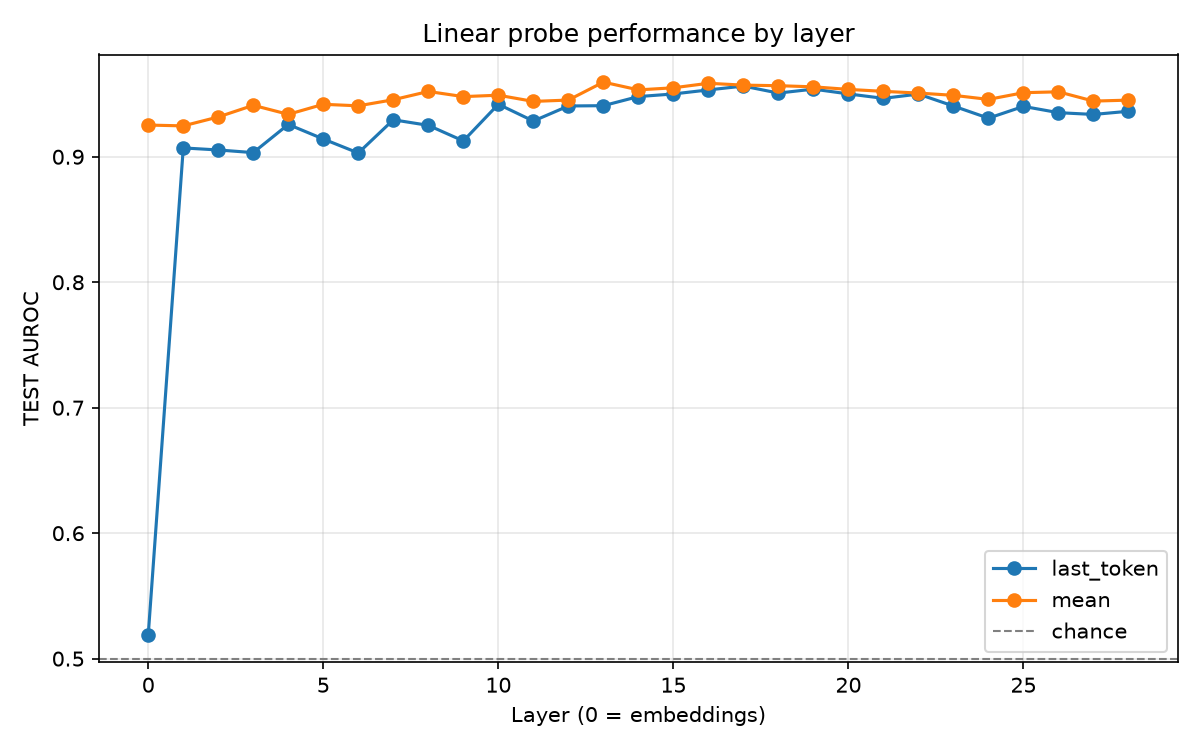

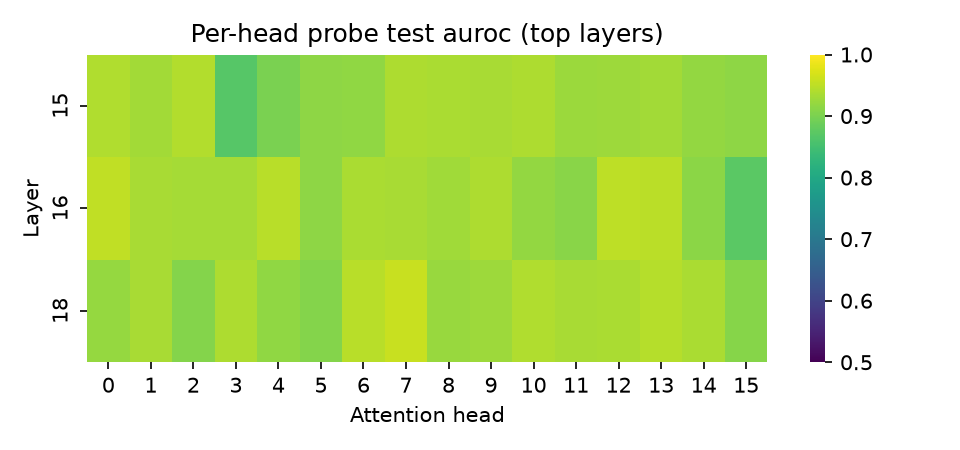

In [21]:
from IPython.display import Image, display

display(Image('results/figures/accuracy_by_layer.png'))
display(Image('results/figures/head_heatmap.png'))

In [22]:
import pandas as pd

pd.read_csv('results/probe_metrics.csv').sort_values('test_auroc', ascending=False).head(10)

,layer,pooling,cv_mean_accuracy,cv_std_accuracy,test_accuracy,test_auroc,n_train,n_test
42,13,mean,0.864375,0.007289,0.8900,0.959500,1600,400
45,16,mean,0.882500,0.013778,0.8900,0.958575,1600,400
46,17,mean,0.881875,0.019705,0.9100,0.957100,1600,400
47,18,mean,0.882500,0.011285,0.9125,0.956650,1600,400
17,17,last_token,0.876250,0.025663,0.8975,0.956350,1600,400
48,19,mean,0.880625,0.018477,0.9075,0.955750,1600,400
44,15,mean,0.880000,0.017744,0.9150,0.954975,1600,400
19,19,last_token,0.888125,0.011592,0.8925,0.953925,1600,400
49,20,mean,0.883125,0.015637,0.8875,0.953700,1600,400
43,14,mean,0.870000,0.014059,0.8775,0.953325,1600,400
